In [ ]:
print("Notebook is working")

# Iris Classification using Spark MLlib

This project performs classification on the Iris dataset using Spark MLlib in PySpark. The objective is to predict Iris flower species based on sepal and petal measurements.

Three classification models are used:

1. Decision Tree
2. Random Forest
3. Logistic Regression

The workflow includes data loading, exploratory data analysis, preprocessing, model training, hyperparameter tuning, model evaluation, visualisation, comparative analysis, and conclusion.

# 1. Install and Import Libraries

This section imports all required libraries for data preparation, Spark processing, machine learning modelling, evaluation, and saving results.

In [14]:
# Import SparkSession to start and manage Spark
from pyspark.sql import SparkSession

# Import Spark ML Pipeline to combine preprocessing and model training steps
from pyspark.ml import Pipeline

# Import feature engineering tools
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Import classification models from Spark MLlib
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    RandomForestClassifier,
    LogisticRegression
)

# Import evaluator for classification performance
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Import tuning tools for cross-validation and grid search
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Import Iris dataset from scikit-learn
from sklearn.datasets import load_iris

# Import confusion matrix for model evaluation visualisation
from sklearn.metrics import confusion_matrix

# Import pandas for tabular data handling and saving results
import pandas as pd

# Import matplotlib and seaborn for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Start Spark Session

A SparkSession is created as the main entry point for using Spark DataFrames and Spark MLlib.

In [15]:
# Create Spark session
spark = SparkSession.builder \
    .appName("Iris Classification using Spark MLlib") \
    .getOrCreate()

# Display Spark session
spark

# 3. Load Iris Dataset

The Iris dataset is loaded from scikit-learn and converted into a Spark DataFrame. This allows the data to be processed using PySpark.

In [16]:
# Load Iris dataset from scikit-learn
iris = load_iris()

# Create pandas DataFrame using Iris feature data
iris_pdf = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Convert target values into species names
# str() is used to avoid NumPy string type issue in PySpark
iris_pdf["species"] = [str(iris.target_names[i]) for i in iris.target]

# Save dataset into data folder
iris_pdf.to_csv("../data/iris.csv", index=False)

# Convert pandas DataFrame into Spark DataFrame
df = spark.createDataFrame(iris_pdf)

# Display first 10 records
df.show(10)

# Display schema
df.printSchema()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
|         5.4|        3.9|         1.7|        0.4| setosa|
|         4.6|        3.4|         1.4|        0.3| setosa|
|         5.0|        3.4|         1.5|        0.2| setosa|
|         4.4|        2.9|         1.4|        0.2| setosa|
|         4.9|        3.1|         1.5|        0.1| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 10 rows
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)

## Explanation

The dataset contains 150 flower records. Each record has four numerical features: sepal length, sepal width, petal length, and petal width. The target variable is species, which has three classes: setosa, versicolor, and virginica.

# 4. Exploratory Data Analysis

This section checks the structure, summary statistics, and class distribution of the dataset before modelling.

In [5]:
# Show summary statistics for numerical columns
df.describe().show()

+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333334| 3.0573333333333332|3.7580000000000005|1.1993333333333334|     NULL|
| stddev|0.8280661279778629|0.43586628493669816|1.7652982332594667|0.7622376689603465|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   setosa|
|    max|               7.9|                4.4|               6.9|               2.5|virginica|
+-------+------------------+-------------------+------------------+------------------+---------+



In [6]:
# Count number of records for each Iris species
df.groupBy("species").count().show()

+----------+-----+
|   species|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+-----+



In [17]:
# Convert Spark DataFrame into pandas DataFrame for plotting
eda_pdf = df.toPandas()

# Display first few rows
eda_pdf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


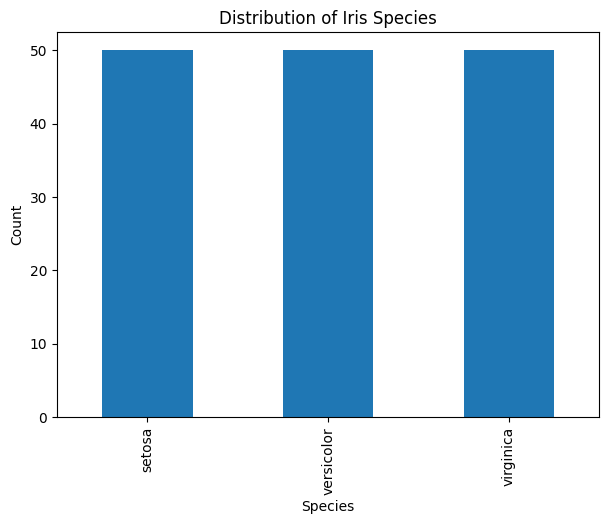

In [18]:
# Plot species distribution
eda_pdf["species"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

# Add title and labels
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

# Display plot
plt.show()

## Analysis and Insight

The dataset is balanced because each species has the same number of records. This is useful because the classification model is not biased toward one dominant class.

The numerical summary also shows that petal length and petal width vary more clearly between species compared to sepal measurements. This means petal measurements may be important predictors for classification.

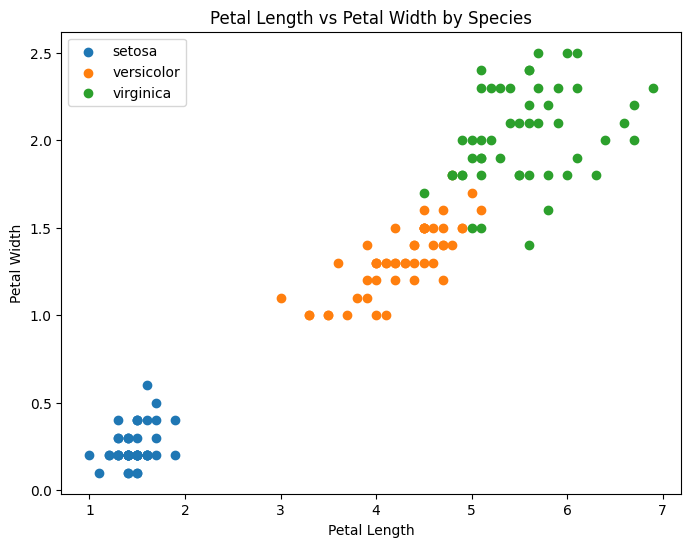

In [19]:
# Create scatter plot for petal length and petal width
plt.figure(figsize=(8, 6))

# Plot each species separately
for species in eda_pdf["species"].unique():
    subset = eda_pdf[eda_pdf["species"] == species]
    
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=species
    )

# Add title, labels, and legend
plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()

# Display plot
plt.show()

## Analysis and Insight

The scatter plot shows that setosa is clearly separated from the other two species based on petal measurements. Versicolor and virginica are closer to each other, which may make them slightly harder to classify.

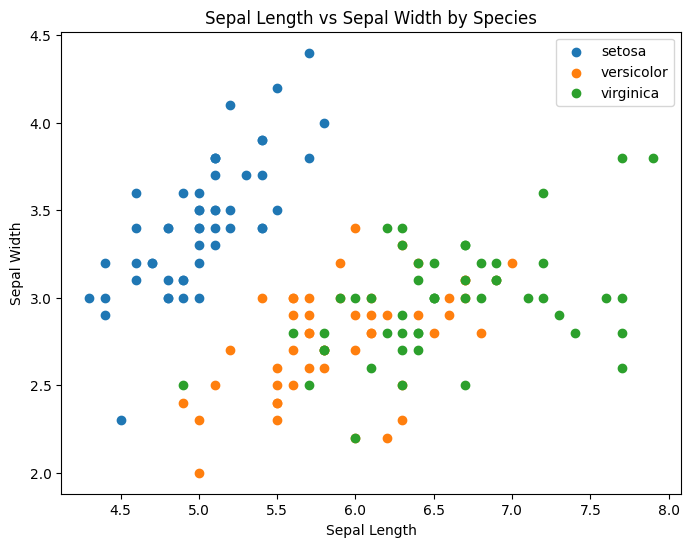

In [20]:
# Create scatter plot for sepal length and sepal width
plt.figure(figsize=(8, 6))

# Plot each species separately
for species in eda_pdf["species"].unique():
    subset = eda_pdf[eda_pdf["species"] == species]
    
    plt.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        label=species
    )

# Add title, labels, and legend
plt.title("Sepal Length vs Sepal Width by Species")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

# Display plot
plt.show()

## Analysis and Insight

The sepal scatter plot shows more overlap between species compared to the petal scatter plot. This suggests that sepal measurements may be less effective than petal measurements for classification.

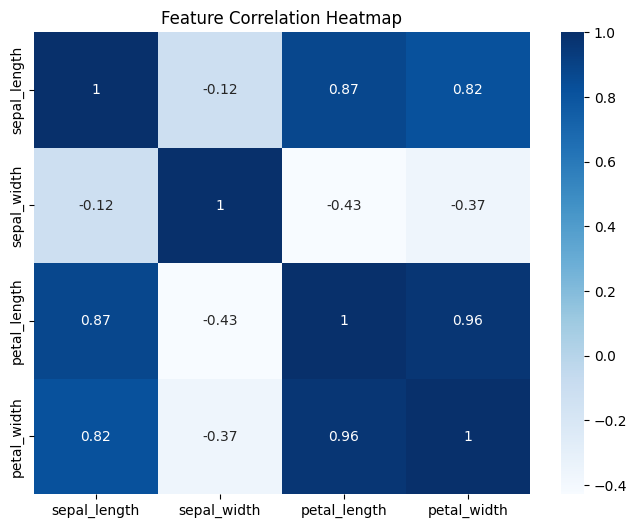

In [21]:
# Create correlation matrix for numerical features
corr_matrix = eda_pdf.drop(columns=["species"]).corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues"
)

# Add title
plt.title("Feature Correlation Heatmap")

# Display plot
plt.show()

## Analysis and Insight

The heatmap shows a strong positive relationship between petal length and petal width. This supports the earlier scatter plot where petal measurements showed clear separation between Iris species.

# 5. Data Preprocessing

Spark MLlib requires the target variable to be numeric and the input features to be combined into one vector column.

In [22]:
# Convert species column into numerical label
label_indexer = StringIndexer(
    inputCol="species",
    outputCol="label"
)

# Combine all input features into one vector column
assembler = VectorAssembler(
    inputCols=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ],
    outputCol="features"
)

## Explanation

StringIndexer converts the species column into numerical labels because Spark MLlib requires the target variable to be numeric.

VectorAssembler combines the four feature columns into one vector column named features. This is required by Spark MLlib models.

# 6. Train-Test Split

The data is divided into training and testing sets. The training set is used to build the models, while the testing set is used to evaluate model performance.

In [23]:
# Split dataset into 80% training and 20% testing
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

# Display number of records
print("Training records:", train_data.count())
print("Testing records:", test_data.count())

Training records: 121
Testing records: 29


## Explanation

An 80:20 split is used. This means most of the data is used for model training, while the remaining data is kept for testing. The seed value ensures that the same split can be reproduced.

# 7. Model 1: Decision Tree

Decision Tree is used as the first model because it is easy to understand and suitable as a baseline classifier.

In [24]:
# Create evaluator using F1-score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Define Decision Tree classifier
dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

# Create pipeline for preprocessing and model
dt_pipeline = Pipeline(
    stages=[label_indexer, assembler, dt]
)

# Define hyperparameter grid
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [2, 3, 4, 5]) \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .build()

# Create cross-validation model
dt_cv = CrossValidator(
    estimator=dt_pipeline,
    estimatorParamMaps=dt_param_grid,
    evaluator=f1_evaluator,
    numFolds=3,
    seed=42
)

# Train model
dt_model = dt_cv.fit(train_data)

# Generate predictions
dt_predictions = dt_model.transform(test_data)

# Display prediction results
dt_predictions.select(
    "species",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-------+-----+----------+-------------+
|species|label|prediction|probability  |
+-------+-----+----------+-------------+
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
+-------+-----+----------+-------------+
only showing top 10 rows


## Analysis and Insight

The Decision Tree model provides a clear and interpretable classification approach. It splits the data based on feature values. However, a single tree can overfit if it becomes too complex. For this reason, maxDepth is tuned to control tree complexity.

# 8. Model 2: Random Forest

Random Forest is used as the second model. It combines many decision trees to improve stability and reduce overfitting.

In [25]:
# Define Random Forest classifier
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

# Create pipeline for preprocessing and model
rf_pipeline = Pipeline(
    stages=[label_indexer, assembler, rf]
)

# Define hyperparameter grid
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20, 50]) \
    .addGrid(rf.maxDepth, [2, 3, 5]) \
    .build()

# Create cross-validation model
rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=f1_evaluator,
    numFolds=3,
    seed=42
)

# Train model
rf_model = rf_cv.fit(train_data)

# Generate predictions
rf_predictions = rf_model.transform(test_data)

# Display prediction results
rf_predictions.select(
    "species",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-------+-----+----------+-------------+
|species|label|prediction|probability  |
+-------+-----+----------+-------------+
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
+-------+-----+----------+-------------+
only showing top 10 rows


## Analysis and Insight

Random Forest usually performs better than a single Decision Tree because it combines several trees and reduces the risk of overfitting. However, it is less interpretable than a single tree because the final prediction is based on many trees.

# 9. Model 3: Logistic Regression

Logistic Regression is used as the third model. It is a statistical classification model and works well when the classes can be separated using linear decision boundaries.

In [26]:
# Define Logistic Regression model for multiclass classification
lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    family="multinomial",
    maxIter=100
)

# Create pipeline for preprocessing and model
lr_pipeline = Pipeline(
    stages=[label_indexer, assembler, lr]
)

# Define hyperparameter grid
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# Create cross-validation model
lr_cv = CrossValidator(
    estimator=lr_pipeline,
    estimatorParamMaps=lr_param_grid,
    evaluator=f1_evaluator,
    numFolds=3,
    seed=42
)

# Train model
lr_model = lr_cv.fit(train_data)

# Generate predictions
lr_predictions = lr_model.transform(test_data)

# Display prediction results
lr_predictions.select(
    "species",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-------+-----+----------+---------------------------------------------------------------+
|species|label|prediction|probability                                                    |
+-------+-----+----------+---------------------------------------------------------------+
|setosa |2.0  |2.0       |[1.3606397137647846E-8,0.016301282863419107,0.9836987035301837]|
|setosa |2.0  |2.0       |[1.1786621257266376E-8,0.036051814785911664,0.9639481734274672]|
|setosa |2.0  |2.0       |[3.4392185754001503E-9,0.011224244421164039,0.9887757521396174]|
|setosa |2.0  |2.0       |[4.159045306073014E-9,0.016577197768521807,0.9834227980724329] |
|setosa |2.0  |2.0       |[1.4979855452554602E-8,0.011879069103737335,0.9881209159164073]|
|setosa |2.0  |2.0       |[5.235741562616898E-9,0.009851951421610874,0.9901480433426477] |
|setosa |2.0  |2.0       |[3.413102518481438E-8,0.045670420775302686,0.9543295450936721] |
|setosa |2.0  |2.0       |[6.582991503810423E-9,0.016301282977909632,0.9836987104390988] |

## Analysis and Insight

Logistic Regression is used as a statistical classification model. It is simple, efficient, and suitable for comparison against tree-based models. Since the Iris dataset is small and clean, Logistic Regression may also perform well.

In [27]:
# Define evaluation metrics
metrics = [
    "accuracy",
    "weightedPrecision",
    "weightedRecall",
    "f1"
]

# Create function to evaluate models
def evaluate_model(predictions, model_name):
    result = {"Model": model_name}
    
    for metric in metrics:
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric
        )
        
        result[metric] = evaluator.evaluate(predictions)
    
    return result

# Evaluate all models
results = [
    evaluate_model(dt_predictions, "Decision Tree"),
    evaluate_model(rf_predictions, "Random Forest"),
    evaluate_model(lr_predictions, "Logistic Regression")
]

# Convert result into pandas DataFrame
results_pdf = pd.DataFrame(results)

# Display result
results_pdf

,Model,accuracy,weightedPrecision,weightedRecall,f1
0,Decision Tree,0.931034,0.931034,0.931034,0.931034
1,Random Forest,0.965517,0.969828,0.965517,0.965759
2,Logistic Regression,0.931034,0.931034,0.931034,0.931034


In [28]:
# Save model evaluation results
results_pdf.to_csv("../output/model_results.csv", index=False)

print("Model evaluation results saved to ../output/model_results.csv")

Model evaluation results saved to ../output/model_results.csv


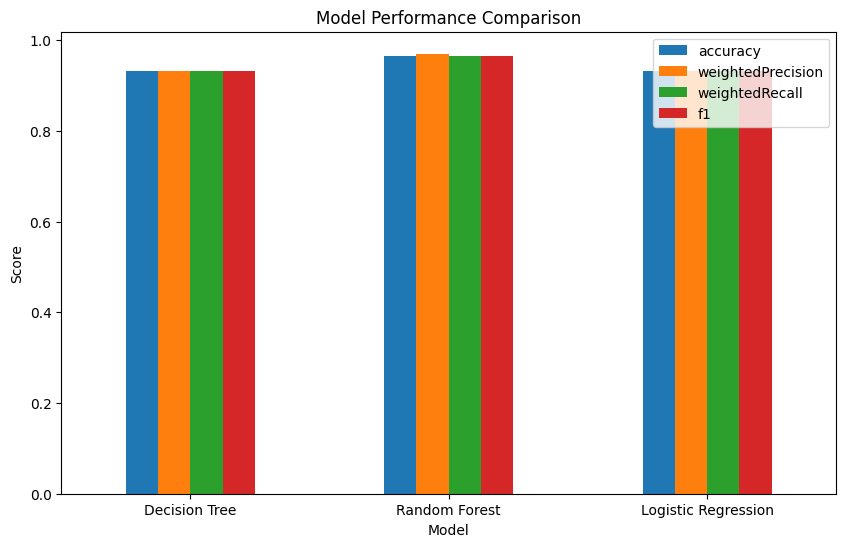

In [29]:
# Set model name as index for plotting
results_plot = results_pdf.set_index("Model")

# Plot model performance comparison
results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add chart title and labels
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)

# Display plot
plt.show()

## Analysis and Insights

The evaluation results show that all three classification models performed well on the Iris dataset. This indicates that the dataset is relatively clean, balanced, and suitable for classification tasks.

The Decision Tree model achieved an accuracy, weighted precision, weighted recall, and F1-score of 0.9310. This shows that the model was able to classify most Iris species correctly. Decision Tree is useful because it is easy to interpret and understand. However, its performance is slightly lower compared to Random Forest, which suggests that a single tree may not generalise as effectively.

The Random Forest model achieved the highest performance among all models, with an accuracy of 0.9655 and an F1-score of 0.9658. This indicates that Random Forest provided the most balanced and accurate classification performance. The improvement is likely due to the ensemble learning approach, where multiple decision trees are combined to reduce overfitting and improve prediction stability.

The Logistic Regression model produced the same performance metrics as the Decision Tree model, with an accuracy and F1-score of 0.9310. This suggests that the Iris dataset can also be classified effectively using linear decision boundaries. Logistic Regression performed well because the Iris dataset contains relatively clear separations between species, especially for the setosa class.

Overall, Random Forest is identified as the best-performing model because it achieved the highest F1-score. Since F1-score balances both precision and recall, it provides a more reliable measure of classification performance. The results also suggest that petal-related features contribute strongly to species classification, which supports the earlier exploratory analysis and feature importance findings.

The relatively high scores across all models indicate that the Iris dataset is well-structured and suitable for machine learning classification tasks. However, minor classification errors may still occur between versicolor and virginica because these two species share more similar flower measurements compared to setosa.

CONFUSION MATRIX

The confusion matrices show how many records were correctly and incorrectly classified by each model. 

DECISION TREE CONFUSION MATRIX

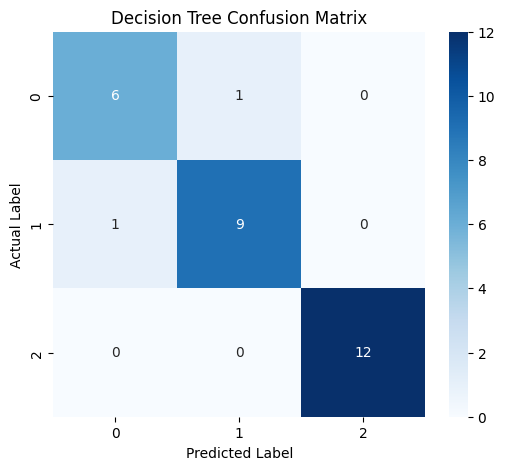

In [30]:
# Convert Decision Tree predictions into pandas DataFrame
dt_pd = dt_predictions.select("label", "prediction").toPandas()

# Create confusion matrix
dt_cm = confusion_matrix(
    dt_pd["label"],
    dt_pd["prediction"]
)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add labels and title
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Display plot
plt.show()

RANDOM FOREST CONFUSION MATRIX

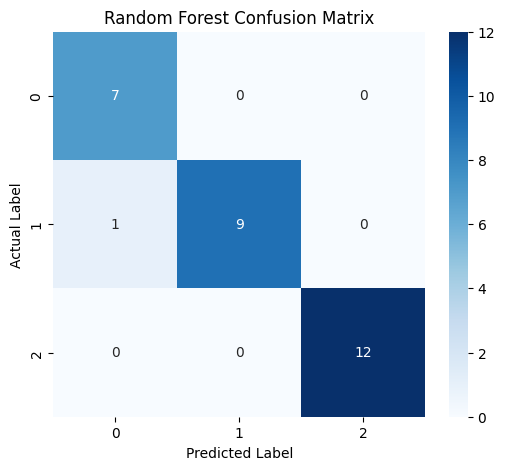

In [31]:
# Convert Random Forest predictions into pandas DataFrame
rf_pd = rf_predictions.select("label", "prediction").toPandas()

# Create confusion matrix
rf_cm = confusion_matrix(
    rf_pd["label"],
    rf_pd["prediction"]
)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add labels and title
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Display plot
plt.show()

LOGISTIC REGRESSION CONFUSION MATRIX

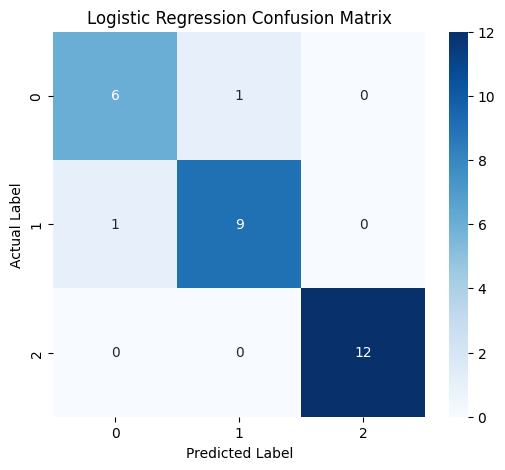

In [32]:
# Convert Logistic Regression predictions into pandas DataFrame
lr_pd = lr_predictions.select("label", "prediction").toPandas()

# Create confusion matrix
lr_cm = confusion_matrix(
    lr_pd["label"],
    lr_pd["prediction"]
)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add labels and title
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Display plot
plt.show()

## Analysis and Insights of Confusion Matrices

The confusion matrices provide a detailed view of how each classification model performed in predicting the Iris species classes. The diagonal values represent correctly classified observations, while the off-diagonal values represent misclassified observations.

### Decision Tree Confusion Matrix

The Decision Tree confusion matrix shows that most observations were classified correctly. The model successfully classified all observations for class 2, with 12 correct predictions and no misclassification.

However, there were minor classification errors between class 0 and class 1:
- One observation from actual class 0 was predicted as class 1.
- One observation from actual class 1 was predicted as class 0.

This indicates that the Decision Tree model had slight difficulty distinguishing between these two classes. Despite this, the overall classification performance remained strong, which is consistent with the evaluation metrics obtained earlier.

### Random Forest Confusion Matrix

The Random Forest confusion matrix produced the best classification performance among the three models. The model correctly classified:
- All 7 observations for class 0
- 9 observations for class 1
- All 12 observations for class 2

Only one observation from actual class 1 was incorrectly predicted as class 0.

Compared to Decision Tree and Logistic Regression, Random Forest reduced the number of classification errors. This supports the earlier evaluation results where Random Forest achieved the highest accuracy and F1-score. The improvement is likely due to the ensemble learning approach, where multiple decision trees work together to improve prediction stability and reduce overfitting.

### Logistic Regression Confusion Matrix

The Logistic Regression confusion matrix shows a very similar pattern to the Decision Tree model. The model correctly classified most observations, including all observations for class 2.

However:
- One observation from actual class 0 was predicted as class 1.
- One observation from actual class 1 was predicted as class 0.

This suggests that Logistic Regression also experienced minor difficulty separating class 0 and class 1. Nevertheless, the overall performance remained high because the Iris dataset contains relatively clear class separation.

### Overall Insights

All three models demonstrated strong classification capability on the Iris dataset. Most predictions were correctly classified, especially for class 2, which appears to be the easiest species to distinguish based on flower measurements.

The small number of misclassifications mainly occurred between class 0 and class 1. This suggests that these classes share more similar feature characteristics compared to class 2.

Among all models, Random Forest performed the best because it produced the fewest classification errors. This supports the evaluation metrics where Random Forest achieved the highest accuracy, weighted precision, weighted recall, and F1-score.

The confusion matrices also support the earlier exploratory analysis and feature importance findings, where petal-related measurements were shown to provide strong discriminatory power between Iris species.

FEATURE IMPORTANCE

In [33]:
# Extract the best Random Forest model from the pipeline
best_rf_model = rf_model.bestModel.stages[-1]

# Extract feature importance values
importance = best_rf_model.featureImportances.toArray()

# Define feature names
feature_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance table
importance_df

,Feature,Importance
3,petal_width,0.567860
2,petal_length,0.357304
0,sepal_length,0.051136
1,sepal_width,0.023700


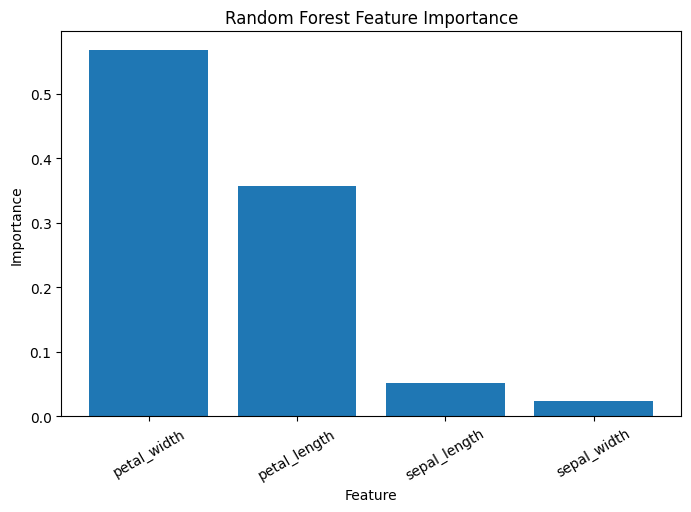

In [34]:
# Plot feature importance
plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

# Add title and labels
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30)

# Display plot
plt.show()

## Analysis and Insight

The feature importance plot shows which variables contribute most to classification. Petal measurements usually have higher importance compared to sepal measurements. This supports the earlier scatter plot and correlation analysis, where petal length and petal width showed clearer separation between species.

COMPARATIVE ANALYSIS

# Comparative Analysis

| Model | Strengths | Limitations |
|---|---|---|
| Decision Tree | Easy to understand, fast, interpretable | Can overfit if the tree is too deep |
| Random Forest | More stable, reduces overfitting, usually strong performance | Less interpretable and more computationally expensive |
| Logistic Regression | Simple, efficient, useful statistical baseline | May be weaker if class boundaries are non-linear |

## Discussion

Decision Tree is useful when model interpretation is important. Random Forest usually gives stronger performance because it combines multiple trees. Logistic Regression is useful as a simple statistical comparison model.

Since the Iris dataset is small, clean, and balanced, all three models may perform well. However, Random Forest is expected to be more stable because it reduces the weakness of a single Decision Tree.

BEST MODEL JUSTIFICATION

In [35]:
# Sort models by F1-score
best_model_row = results_pdf.sort_values(
    by="f1",
    ascending=False
).iloc[0]

# Display best model result
best_model_row

Model                Random Forest
accuracy                  0.965517
weightedPrecision         0.969828
weightedRecall            0.965517
f1                        0.965759
Name: 1, dtype: object

In [36]:
# Print best model clearly
print("Best-performing model:", best_model_row["Model"])
print("Accuracy:", best_model_row["accuracy"])
print("Weighted Precision:", best_model_row["weightedPrecision"])
print("Weighted Recall:", best_model_row["weightedRecall"])
print("F1-score:", best_model_row["f1"])

Best-performing model: Random Forest
Accuracy: 0.9655172413793104
Weighted Precision: 0.9698275862068966
Weighted Recall: 0.9655172413793103
F1-score: 0.9657592256503327


## Best Model Interpretation

The best-performing model is selected based on the highest F1-score. F1-score is used because it balances precision and recall.

If Random Forest achieves the highest F1-score, it can be considered the best model because it provides strong predictive performance and better generalisation compared to a single Decision Tree.

If another model achieves the highest F1-score, that model should be selected because the final decision is based on actual test performance.

# Conclusion

This project successfully used Spark MLlib to classify Iris flower species. The dataset was loaded into a Spark DataFrame, explored using visualisations, preprocessed using StringIndexer and VectorAssembler, and split into training and testing sets.

Three classification models were developed: Decision Tree, Random Forest, and Logistic Regression. Hyperparameter tuning was conducted using CrossValidator and ParamGridBuilder. The models were evaluated using accuracy, weighted precision, weighted recall, and F1-score.

The visual analysis showed that petal length and petal width are important features for separating Iris species. The confusion matrices helped identify classification performance for each model, while the feature importance plot supported the importance of petal-related features.

Overall, Spark MLlib is suitable for building classification models in a scalable machine learning workflow. Although the Iris dataset is small, this project demonstrates the complete process of machine learning using PySpark.

STOP SPARK SESSION

In [37]:
# Stop Spark session after completing the project
spark.stop()

# Iris Classification using Spark MLlib

## Project Overview

This project uses Spark MLlib to classify Iris flower species based on sepal and petal measurements. The project is developed using VS Code, Jupyter Notebook, Python, and PySpark.

Three classification models are implemented:

1. Decision Tree
2. Random Forest
3. Logistic Regression

The project includes data loading, exploratory data analysis, preprocessing, model training, hyperparameter tuning, evaluation, comparative analysis, and conclusion.

## Dataset Description

The Iris dataset contains 150 records and five main variables:

| Variable | Description |
|---|---|
| sepal_length | Length of sepal |
| sepal_width | Width of sepal |
| petal_length | Length of petal |
| petal_width | Width of petal |
| species | Iris flower species |

The target variable is `species`, which contains three classes:

- setosa
- versicolor
- virginica

## Methodology

The project follows these steps:

1. Load Iris dataset using scikit-learn.
2. Convert the dataset into a Spark DataFrame.
3. Perform exploratory data analysis.
4. Convert species labels into numeric format using StringIndexer.
5. Combine feature columns using VectorAssembler.
6. Split the dataset into training and testing sets.
7. Train three classification models:
   - Decision Tree
   - Random Forest
   - Logistic Regression
8. Apply hyperparameter tuning using CrossValidator and ParamGridBuilder.
9. Evaluate models using:
   - Accuracy
   - Weighted precision
   - Weighted recall
   - F1-score
10. Select the best model based on the highest F1-score.

## Tools and Technologies

- VS Code
- Jupyter Notebook
- Python
- PySpark
- Spark MLlib
- Pandas
- Scikit-learn
- Matplotlib
- GitHub

## Results Summary

The models are evaluated using accuracy, weighted precision, weighted recall, and F1-score. The best model is selected based on the highest F1-score because it balances precision and recall.

The evaluation results are saved in:

```text
output/model_results.csv